In [1]:
import os
import torch
import yaml

from daart.models import Segmenter

model_dir = '/media/mattw/ibl2/segmentation/classifiers/multi-0/dtcn/10-session/version_0'
model_file = os.path.join(model_dir, 'best_val_model.pt')

hparams_file = os.path.join(model_dir, 'hparams.yaml')
hparams = yaml.safe_load(open(hparams_file, 'rb'))

model = Segmenter(hparams)
model.load_state_dict(torch.load(model_file, map_location=lambda storage, loc: storage))
model.to(hparams['device'])
model.eval()

Segmenter(
  (model): ModuleDict(
    (encoder): DilatedTCN(
      (model): Sequential(
        (tcn_block_00): DilationBlock(
          (conv0): Conv1d(6, 32, kernel_size=(9,), stride=(1,), padding=(4,))
          (conv1): Conv1d(32, 32, kernel_size=(9,), stride=(1,), padding=(4,))
          (activation): LeakyReLU(negative_slope=0.05)
          (final_activation): LeakyReLU(negative_slope=0.05)
          (dropout): Dropout2d(p=0.1, inplace=False)
          (block): Sequential(
            (conv1d_layer_0): Conv1d(6, 32, kernel_size=(9,), stride=(1,), padding=(4,))
            (lrelu_0): LeakyReLU(negative_slope=0.05)
            (dropout_0): Dropout2d(p=0.1, inplace=False)
            (conv1d_layer_1): Conv1d(32, 32, kernel_size=(9,), stride=(1,), padding=(4,))
            (lrelu_1): LeakyReLU(negative_slope=0.05)
            (dropout_1): Dropout2d(p=0.1, inplace=False)
          )
          (downsample): Conv1d(6, 32, kernel_size=(1,), stride=(1,))
        )
        (tcn_block_01): 

In [2]:
from daart.data import DataGenerator
from daart.transforms import ZScore

sess_id = 'churchlandlab_CSHL045_2020-02-27-001'
input_file = '/home/mattw/Dropbox/shared/segmentation-data/ibl/features-posvel/churchlandlab_CSHL045_2020-02-27-001_labeled.csv'

# define data generator signals
signals = ['markers']  # same for markers or features
transforms = [ZScore()]
paths = [input_file]

# build data generator
data_gen_test = DataGenerator(
    [sess_id], [signals], [transforms], [paths], device=hparams['device'],
    sequence_length=hparams['sequence_length'], batch_size=hparams['batch_size'],
    trial_splits=hparams['trial_splits'],
    sequence_pad=hparams['sequence_pad'], input_type=hparams['input_type'],
)

In [3]:
import numpy as np

# predict probabilities from model
print('computing states for %s...' % sess_id, end='')
tmp = model.predict_labels(data_gen_test, return_scores=True)
probs = np.vstack(tmp['labels'][0])
print('done')

# get discrete state by taking argmax over probabilities at each time point
states = np.argmax(probs, axis=1)

computing states for churchlandlab_CSHL045_2020-02-27-001...done


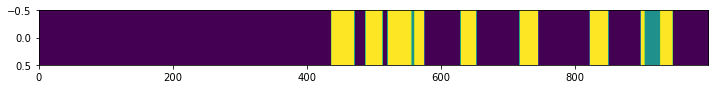

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 1))
plt.imshow(states[None, :1000], aspect='auto')
plt.show()